In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import scipy as sp

Exampls for Bayesian Inference

# Example 1

### Generate dummy data


In [2]:
np.random.seed(42)
true_mu = 5
true_sigma = 2
data = np.random.normal(true_mu, true_sigma, size=100)

### Definition prior hyperparameters

In [3]:
prior_mu_mean = 0
prior_mu_precision = 1  # Variance = 1 / precision

prior_sigma_alpha = 2
prior_sigma_beta = 2  # Beta = alpha / beta

### Update prior hyperparameters with example data (fitting)

In [4]:
posterior_mu_precision = prior_mu_precision + len(data) / true_sigma**2
posterior_mu_mean = (prior_mu_precision * prior_mu_mean + np.sum(data)) / posterior_mu_precision

posterior_sigma_alpha = prior_sigma_alpha + len(data) / 2
posterior_sigma_beta = prior_sigma_beta + np.sum((data - np.mean(data))**2) / 2


### Calculate the posterior parameters

In [5]:
posterior_mu = np.random.normal(posterior_mu_mean, 1 / np.sqrt(posterior_mu_precision), size=10000)
posterior_sigma = np.random.gamma(posterior_sigma_alpha, 1 / posterior_sigma_beta, size=10000)


## Results

### Plot Posterior Distribution

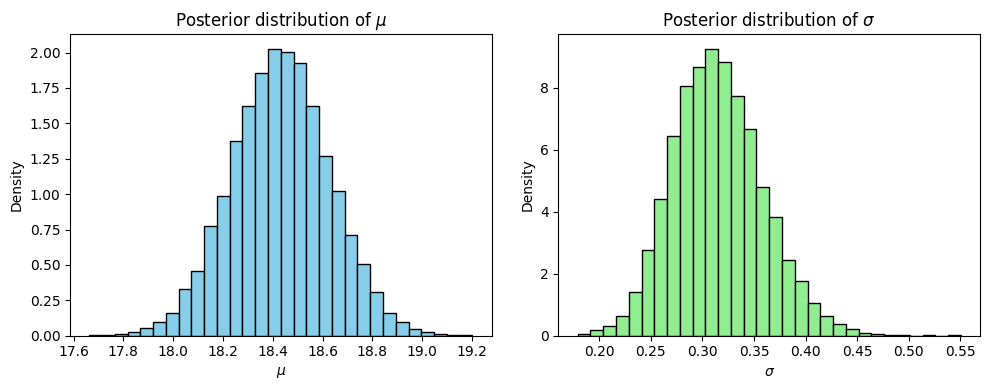

In [6]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(posterior_mu, bins=30, density=True, color='skyblue', edgecolor='black')
plt.title('Posterior distribution of $\mu$')
plt.xlabel('$\mu$')
plt.ylabel('Density')

plt.subplot(1, 2, 2)
plt.hist(posterior_sigma, bins=30, density=True, color='lightgreen', edgecolor='black')
plt.title('Posterior distribution of $\sigma$')
plt.xlabel('$\sigma$')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

### Summary statistics

In [7]:
mean_mu = np.mean(posterior_mu)
std_mu = np.std(posterior_mu)
print("Mean of mu:", mean_mu)
print("Standard deviation of mu:", std_mu)

mean_sigma = np.mean(posterior_sigma)
std_sigma = np.std(posterior_sigma)
print("Mean of sigma:", mean_sigma)
print("Standard deviation of sigma:", std_sigma)

Mean of mu: 18.431718658085725
Standard deviation of mu: 0.19684004415211634
Mean of sigma: 0.314978331043776
Standard deviation of sigma: 0.043338268607342946


-----


# Example 2
Predicting Website Conversion Rates with Bayesian Inference

In [8]:
# Observed data
num_visitors = 1000  # Total number of visitors to the website
num_conversions = 50  # Number of conversions (desired actions)


### Prior hyperparameters for the Beta distribution

In [9]:
prior_alpha = 1  # Shape parameter
prior_beta = 1   # Shape parameter

### Fitting - Update Prior with Observed Data == Posterior Parameters

In [10]:
posterior_alpha = prior_alpha + num_conversions
posterior_beta = prior_beta + (num_visitors - num_conversions)


### Generate Samples from the Posterior Beta Distribution

In [12]:
posterior_samples = np.random.beta(posterior_alpha, posterior_beta, size=10000)

## Results

### Plot Posterior Distribution

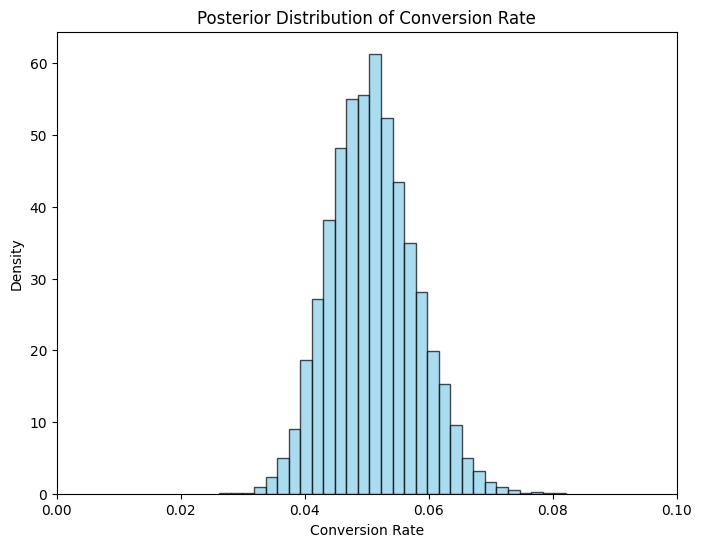

In [13]:
plt.figure(figsize=(8, 6))
plt.hist(posterior_samples, bins=30, density=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Posterior Distribution of Conversion Rate')
plt.xlabel('Conversion Rate')
plt.ylabel('Density')
plt.xlim(0, 0.1)  # Limiting x-axis to focus on conversion rates close to zero
plt.show()


### Calculate Summary Statistics

In [14]:
mean_conversion_rate = posterior_alpha / (posterior_alpha + posterior_beta)
mode_conversion_rate = (posterior_alpha - 1) / (posterior_alpha + posterior_beta - 2)  # Mode of the Beta distribution

print("Mean conversion rate:", mean_conversion_rate)
print("Mode conversion rate:", mode_conversion_rate)

Mean conversion rate: 0.05089820359281437
Mode conversion rate: 0.05


---

# Example 3


[How to use Bayesian Inference for predictions in Python](https://towardsdatascience.com/how-to-use-bayesian-inference-for-predictions-in-python-4de5d0bc84f3/)


**Sneaky Advanced Note** 

I'm using the uniform distribution for clarity, but we can also make the beta distribution look completely flat by tweaking alpha and beta!

In [ ]:
mu = np.linspace(1.65, 1.8, num = 50)
test = np.linspace(0, 2)

uniform_dist = sp.stats.uniform.pdf(mu) + 1 

NameError: name 'sts' is not defined

In [16]:
# Normalizing the distribution to make the probability densities sum into 1
uniform_dist = uniform_dist/uniform_dist.sum() 
beta_dist = sts.beta.pdf(mu, 2, 5, loc = 1.65, scale = 0.2) 
beta_dist = beta_dist/beta_dist.sum()

NameError: name 'uniform_dist' is not defined

In [17]:
plt.plot(mu, beta_dist, label = 'Beta Dist')
plt.plot(mu, uniform_dist, label = 'Uniform Dist')
plt.xlabel("Value of $\mu$ in meters")
plt.ylabel("Probability density")
plt.legend()

NameError: name 'beta_dist' is not defined